## Download dataset from roboflow API

In [1]:
from roboflow import Roboflow
rf = Roboflow(api_key="iKZYuqo7DE6nATajKlqs")
project = rf.workspace("wrkspc-gi0hz").project("cloud-classification-mf91q")
version = project.version(7)
dataset = version.download("tensorflow")           

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cloud-Classification-7 in tensorflow:: 100%|█████████████████████████████████████████████████████████| 1759/1759 [00:00<00:00, 16496.58it/s]


#### Encode the class into int32

In [1]:
CLASS_NAMES = [
    "altocumulus",
    "altostratus",
    "cirrocumulus",
    "cirrostratus",
    "cirrus",
    "cumulonimbus",
    "cumulus",
    "nimbostratus",
    "stratocumulus",
    "stratus",
]

#### Prepare the dataset

In [2]:
IMG_SIZE = (224, 224)
def prepare_dataset(records, image_path):
    images = []
    targets = []
    labels = []
    for index, row in records.iterrows():
        (filename, width, height, class_name, xmin, ymin, xmax, ymax) = row
        
        fullpath = os.path.join(image_path, filename)
        img = keras.preprocessing.image.load_img(fullpath, target_size=(IMG_SIZE[0], IMG_SIZE[1]))
        img_arr = keras.preprocessing.image.img_to_array(img)
        
        # Convert into porportion of the image size
        xmin = round(xmin/ width, 2)
        ymin = round(ymin/ height, 2)
        xmax = round(xmax/ width, 2)
        ymax = round(ymax/ height, 2)
        
        images.append(img_arr)
        targets.append((xmin, ymin, xmax, ymax))
        labels.append(CLASS_NAMES.index(class_name))
    return images, targets, labels

In [3]:
import os
import pandas as pd
from tensorflow import keras

# Train set
TRAINING_CSV_FILE = 'Cloud-Classification-7/train/_annotations.csv'
TRAINING_IMAGE_DIR = 'Cloud-Classification-7/train'

training_image_records = pd.read_csv(TRAINING_CSV_FILE)

train_image_path = os.path.join(os.getcwd(), TRAINING_IMAGE_DIR)

train_images, train_targets, train_labels = prepare_dataset(training_image_records, train_image_path)

# Validate set
VALIDATING_CSV_FILE = 'Cloud-Classification-7/valid/_annotations.csv'
VALIDATING_IMAGE_DIR = 'Cloud-Classification-7/valid'

validating_image_records = pd.read_csv(VALIDATING_CSV_FILE)

valid_image_path = os.path.join(os.getcwd(), VALIDATING_IMAGE_DIR)

valid_images, valid_targets, valid_labels = prepare_dataset(validating_image_records, valid_image_path)

# Testing set
TESTING_CSV_FILE = 'Cloud-Classification-7/test/_annotations.csv'
TESTING_IMAGE_DIR = 'Cloud-Classification-7/test'

testing_image_records = pd.read_csv(TESTING_CSV_FILE)

test_image_path = os.path.join(os.getcwd(), TESTING_IMAGE_DIR)

test_images, test_targets, test_labels = prepare_dataset(testing_image_records, test_image_path)

2026-01-24 01:13:13.592492: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-24 01:13:13.599123: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769191993.606894   21648 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769191993.610110   21648 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-24 01:13:13.618601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [4]:
import numpy as np

train_images = np.array(train_images)
train_targets = np.array(train_targets)
train_labels = np.array(train_labels)

valid_images = np.array(valid_images)
valid_targets = np.array(valid_targets)
valid_labels = np.array(valid_labels)

test_images = np.array(test_images)
test_targets = np.array(test_targets)
test_labels = np.array(test_labels)

### Custom CNN Architecture

In [ ]:
num_classes = len(CLASS_NAMES)

#create the common input layer
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

input_layer = tf.keras.layers.Input(input_shape)

#create the base layers
base_layers = layers.Rescaling(1./255, name='bl_1')(input_layer)
base_layers = layers.Conv2D(16, 3, padding='same', activation='relu', name='bl_2')(base_layers)
base_layers = layers.MaxPooling2D(name='bl_3')(base_layers)
base_layers = layers.Conv2D(32, 3, padding='same', activation='relu', name='bl_4')(base_layers)
base_layers = layers.MaxPooling2D(name='bl_5')(base_layers)
base_layers = layers.Conv2D(64, 3, padding='same', activation='relu', name='bl_6')(base_layers)
base_layers = layers.MaxPooling2D(name='bl_7')(base_layers)
base_layers = layers.Flatten(name='bl_8')(base_layers)

#create the classifier branch
classifier_branch = layers.Dense(128, activation='relu', name='cl_1')(base_layers)
classifier_branch = layers.Dense(num_classes, name='cl_head')(classifier_branch)  

#create the localiser branch
locator_branch = layers.Dense(128, activation='relu', name='bb_1')(base_layers)
locator_branch = layers.Dense(64, activation='relu', name='bb_2')(locator_branch)
locator_branch = layers.Dense(32, activation='relu', name='bb_3')(locator_branch)
locator_branch = layers.Dense(4, activation='sigmoid', name='bb_head')(locator_branch)

model = tf.keras.Model(input_layer,
           outputs=[classifier_branch,locator_branch])
model.summary()

In [9]:
losses = {"cl_head":tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
   "bb_head":tf.keras.losses.MSE}
model.compile(loss=losses, optimizer='Adam', metrics=[['accuracy'], []])

In [10]:
trainTargets = {
    "cl_head": train_labels,
    "bb_head": train_targets
}
validTargets = {
    "cl_head": valid_labels,
    "bb_head": valid_targets
}
training_epochs = 20

In [11]:
history = model.fit(train_images, trainTargets,
             validation_data=(valid_images, validTargets),
             batch_size=4,
             epochs=training_epochs,
             shuffle=True,
             verbose=1)

Epoch 1/20


I0000 00:00:1769192131.824603   21757 service.cc:148] XLA service 0x7f0698006c30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769192131.824643   21757 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-24 01:15:31.862286: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769192132.012310   21757 cuda_dnn.cc:529] Loaded cuDNN version 90101


 27/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - bb_head_loss: 0.0739 - cl_head_accuracy: 0.1331 - cl_head_loss: 3.5266 - loss: 3.6005

I0000 00:00:1769192135.151174   21757 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


390/390 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - bb_head_loss: 0.0217 - cl_head_accuracy: 0.2272 - cl_head_loss: 2.1841 - loss: 2.2064 - val_bb_head_loss: 0.0158 - val_cl_head_accuracy: 0.3243 - val_cl_head_loss: 1.9723 - val_loss: 1.9882
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - bb_head_loss: 0.0155 - cl_head_accuracy: 0.4705 - cl_head_loss: 1.5844 - loss: 1.6015 - val_bb_head_loss: 0.0145 - val_cl_head_accuracy: 0.4189 - val_cl_head_loss: 1.8990 - val_loss: 1.9136
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - bb_head_loss: 0.0122 - cl_head_accuracy: 0.7169 - cl_head_loss: 0.8643 - loss: 0.8776 - val_bb_head_loss: 0.0156 - val_cl_head_accuracy: 0.4797 - val_cl_head_loss: 1.9152 - val_loss: 1.9309
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - bb_head_loss: 0.0101 - cl_head_accuracy: 0.8935 - cl_head_loss: 0.3801 - loss: 0.3907 - val_bb_head_loss: 0.0173 - val_cl_head_accuracy: 0.4662 - val_cl_head_loss: 2.8644 - val_loss: 2.8817
Epoch 5/20
390/390 ━━━━━━━━━━━━━━

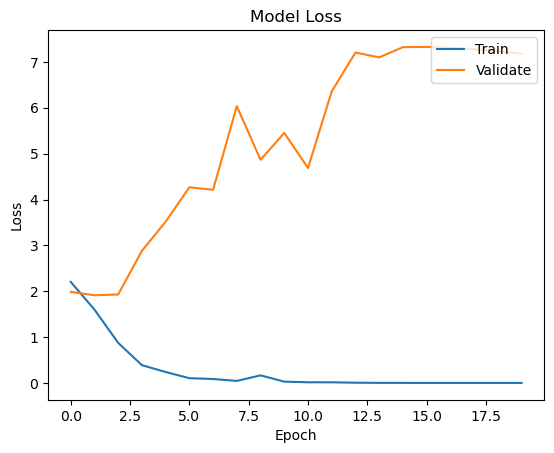

In [13]:
import matplotlib
import matplotlib.pyplot as plt

# Plot Model Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validate'], loc='upper right')
plt.show()

### MobileNetV2

In [16]:
base_model = keras.applications.MobileNetV2(
    include_top=False, 
    weights='imagenet', 
    input_shape=input_shape
)
base_model.trainable = True

In [41]:
# Freezing layer
i = 0
for layer in base_model.layers[:84]:
    layer.trainable = False

In [42]:
inputs = keras.Input(shape=input_shape)
x = keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=True)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

class_output = keras.layers.Dense(
    num_classes,
    activation="softmax",
    name="cl_head"
)(x)

bbox_output = keras.layers.Dense(
    4,
    activation="sigmoid",
    name="bb_head"
)(x)

mobilenet_model = keras.Model(
    inputs=inputs,
    outputs=[class_output, bbox_output]
)

In [52]:
mobilenet_model.compile(loss=losses, optimizer=keras.optimizers.Adam(learning_rate=1e-4), metrics=[['accuracy'], []])

In [53]:
from keras.callbacks import ModelCheckpoint

mobilenet_path = 'best_mobilenetv2.keras'
checkpoint = ModelCheckpoint(mobilenet_path, verbose=1, mode='max')
callbacks_list = [checkpoint]
history = mobilenet_model.fit(train_images, trainTargets,
             validation_data=(valid_images, validTargets),
             batch_size=32,
             epochs=training_epochs,
             shuffle=True,
             verbose=1,
             callbacks=callbacks_list
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - bb_head_loss: 0.0073 - cl_head_accuracy: 1.0000 - cl_head_loss: 2.0508e-04 - loss: 0.0075
Epoch 1: saving model to best_mobilenetv2.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step - bb_head_loss: 0.0075 - cl_head_accuracy: 1.0000 - cl_head_loss: 1.9804e-04 - loss: 0.0077 - val_bb_head_loss: 0.0139 - val_cl_head_accuracy: 0.5946 - val_cl_head_loss: 2.1582 - val_loss: 2.0520
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - bb_head_loss: 0.0075 - cl_head_accuracy: 1.0000 - cl_head_loss: 1.4880e-04 - loss: 0.0076
Epoch 2: saving model to best_mobilenetv2.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - bb_head_loss: 0.0071 - cl_head_accuracy: 1.0000 - cl_head_loss: 1.5269e-04 - loss: 0.0073 - val_bb_head_loss: 0.0138 - val_cl_head_accuracy: 0.6014 - val_cl_head_loss: 2.1965 - val_loss: 2.0885
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - bb_head_loss: 0.0064 - cl_head_accuracy: 1.0000 - cl_head_loss: 1.5281e-04 - loss: 0.0065


KeyboardInterrupt: 

In [ ]:
# Plot Model Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validate'], loc='upper right')
plt.show()